In [1]:
!pip install dataframe_image
import pystac_client
import planetary_computer
import xarray as xr
import rasterio as rio
import rioxarray
import geopandas as gpd
import odc.stac
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import os
import rasterstats
from rioxarray import merge
import scipy.ndimage as ndimage
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.measure import label
from shapely.geometry import shape
from rasterio.features import shapes, rasterize
import xyzservices.providers as xyz
from datetime import datetime
import datetime
import dataframe_image as dfi

  Using cached dataframe_image-0.2.7-py3-none-any.whl.metadata (9.3 kB)
  Using cached cssutils-2.11.1-py3-none-any.whl.metadata (8.7 kB)
  Using cached playwright-1.58.0-py3-none-manylinux1_x86_64.whl.metadata (3.5 kB)
  Using cached cssselect-1.4.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached more_itertools-10.8.0-py3-none-any.whl.metadata (39 kB)
  Using cached pyee-13.0.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached greenlet-3.3.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (3.7 kB)
Using cached dataframe_image-0.2.7-py3-none-any.whl (6.7 MB)
Using cached cssselect-1.4.0-py3-none-any.whl (18 kB)
Using cached cssutils-2.11.1-py3-none-any.whl (385 kB)
Using cached playwright-1.58.0-py3-none-manylinux1_x86_64.whl (46.2 MB)
Using cached greenlet-3.3.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (594 kB)
Using cached pyee-13.0.1-py3-none-any.whl (15 kB)
Using cached more_itertools-10.8.0-py3-none-any.whl (69 kB)
  Attempting uninstall: 

## Downloading Sentinel images (mostly adapted from Quinn's 04_demo_download)

In [2]:
# Connect to Planetary Computer STAC
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

# Mui Ca Mau bounding box
bbox = [104.7, 8.55, 104.9, 8.7]

In [3]:
#Choose dry season months
def filter_dry_season(items, dry_season_months=[12, 1, 2, 3, 4]):
    filtered = [
        item for item in items
        if item.datetime.month in dry_season_months
    ]
    print(f"  {len(items)} total → {len(filtered)} dry season scenes")
    return filtered

In [4]:
#Find dry season images from 2016 and 2017- had to include this because 2016 alone didn't have enough images
search_2017 = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2015-11-01/2017-04-30",  # spans two dry seasons
    query={"eo:cloud_cover": {"lt": 25}} #25 percent
)

items_2017_all = list(search_2017.items())
items_2017 = filter_dry_season(items_2017_all)

  7 total → 6 dry season scenes


In [5]:
#Search the catalog for rasters within out bbox and time. Print the items found

search_2026 = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2025-11-01/2026-04-30",
    query={"eo:cloud_cover": {"lt": 25}}
)

items_2026 = list(search_2026.items())
print(f"Found {len(items_2026)} scenes for 2026")

Found 7 scenes for 2026


In [6]:
items_2017_48PVQ = [
    item for item in items_2017
    if item.properties["s2:mgrs_tile"] == "48PVQ"
]

items_2026_48PVQ = [
    item for item in items_2026
    if item.properties["s2:mgrs_tile"] == "48PVQ"
]

print(f"2017: {len(items_2017_48PVQ)} scenes")
print(f"2026: {len(items_2026_48PVQ)} scenes")

2017: 6 scenes
2026: 7 scenes


In [7]:
bands = ["B03", "B04", "B08", "B11", "SCL"]  #  Green, Red, NIR,SWIR, SLC

In [8]:
#Creating our datasets for each individual year
camau_2017_s2_ds = odc.stac.load(
    items_2017_48PVQ,
    bands=bands,
    chunks={"x": 256, "y": 256},
    groupby="solar_day",
    bbox=bbox,
    crs="EPSG:32648",
    resolution=10
)

camau_2026_s2_ds = odc.stac.load(
    items_2026_48PVQ,
    bands=bands,
    chunks={"x": 256, "y": 256},
    groupby="solar_day",
    bbox=bbox,
    crs="EPSG:32648",
    resolution=10
)

In [9]:
camau_2026_s2_da = camau_2026_s2_ds.to_array(dim='band')

# Harmonizing data
While interpreting the MNDWI data, we found a lot of discrepancies and through research discovered Sentinel changed methods in 2022, making it so reflectance values could be negative. In order to circumvent this change we included this harmonize_to_old function offered by planetary computer on Microsoft.

https://planetarycomputer.microsoft.com/dataset/sentinel-2-l2a#Baseline-Change

In [10]:
def harmonize_to_old(data):
    """
    Harmonize new Sentinel-2 data to the old baseline.

    Parameters
    ----------
    data: xarray.DataArray
        A DataArray with four dimensions: time, band, y, x

    Returns
    -------
    harmonized: xarray.DataArray
        A DataArray with all values harmonized to the old
        processing baseline.
    """

    cutoff = datetime.datetime(2022, 1, 25)
    offset = 1000
    bands = [
        "B01",
        "B02",
        "B03",
        "B04",
        "B05",
        "B06",
        "B07",
        "B08",
        "B8A",
        "B09",
        "B10",
        "B11",
        "B12",
    ]

    old = data.sel(time=slice(cutoff))

    to_process = list(set(bands) & set(data.band.data.tolist()))
    new = data.sel(time=slice(cutoff, None)).drop_sel(band=to_process)

    new_harmonized = data.sel(time=slice(cutoff, None), band=to_process).clip(offset)
    new_harmonized -= offset

    new = xr.concat([new, new_harmonized], "band").sel(band=data.band.data.tolist())
    return xr.concat([old, new], dim="time")

In [11]:
camau_2026_s2_da_harmonized = harmonize_to_old(camau_2026_s2_da)
camau_2026_s2_ds = camau_2026_s2_da_harmonized.to_dataset(dim='band')

In [12]:
# Originally we had done scaling but in further research found that scaling process for this data obsolete (mostly used for landsat?)
# Now there is only masking here


def mask_and_scale(ds):
    bad_scl = [0, 1, 8, 9]
    valid = ~ds["SCL"].isin(bad_scl)
    
    spectral_bands = ["B03", "B04", "B08", "B11"]
    masked = ds[spectral_bands].where(valid) 
    return masked

masked_2017 = mask_and_scale(camau_2017_s2_ds)
masked_2026 = mask_and_scale(camau_2026_s2_ds)

In [ ]:
# Median composite
comp_2017 = masked_2017.median(dim="time", skipna=True).compute()
comp_2026 = masked_2026.median(dim="time", skipna=True).compute()

/opt/conda/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


In [ ]:
#And indices function
def add_indices(ds):
    G   = ds["B03"]
    R   = ds["B04"]
    NIR = ds["B08"]
    S1  = ds['B11']

    ds["NDVI"]  = (NIR - R)   / (NIR + R)
    ds["NDWI"]  = (G - NIR)   / (G + NIR)
    ds["MNDWI"] = (G - S1)    / (G + S1)
    ds["CMRI"]  = ds["NDVI"] - ds["NDWI"]
    return ds.compute()

In [ ]:
comp_2017 = add_indices(comp_2017)
comp_2026 = add_indices(comp_2026)

In [ ]:
for da, year in [(comp_2017, "2017"), (comp_2026, "2026")]:
    da.rio.write_crs("EPSG:32648", inplace=True)
    da.rio.to_raster(f"ca_mau_{year}_48PVQ.tif")
    print(f"Exported ca_mau_{year}_48PVQ.tif")

# Comparisons 

## NDVI
- NDVI (Low, positive values represent shrub and grassland (approximately 0.2 to 0.4), while high values indicate temperate and tropical rainforests (values approaching 1). It is a good proxy for live green vegetation; see [1] for details. -https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndvi/). The measured data in Tumpat, Kelantan Delta, on the east coast of Peninsular Malaysia, showed that young/growing and mature mangroves with high coverage had higher NDVI values (0.4–0.68) and healthier conditions than mangroves with environmental stress (0.38–0.47) -https://www.sciencedirect.com/science/article/abs/pii/S0048969722041729. (what is our spatial distribution?) --> Mangroves are often mixed with water bodies, mudflats or other coastal vegetation types in satellite image pixels; therefore, mangrove information is overwhelmed by other land cover types in pixels with low mangrove coverage. Therefore, only pixels with >75 % mangrove coverage were considered for the following analysis. The proportion of selected pixels in the global mangrove area was 66.13 %. important to note ---? how do we go around this?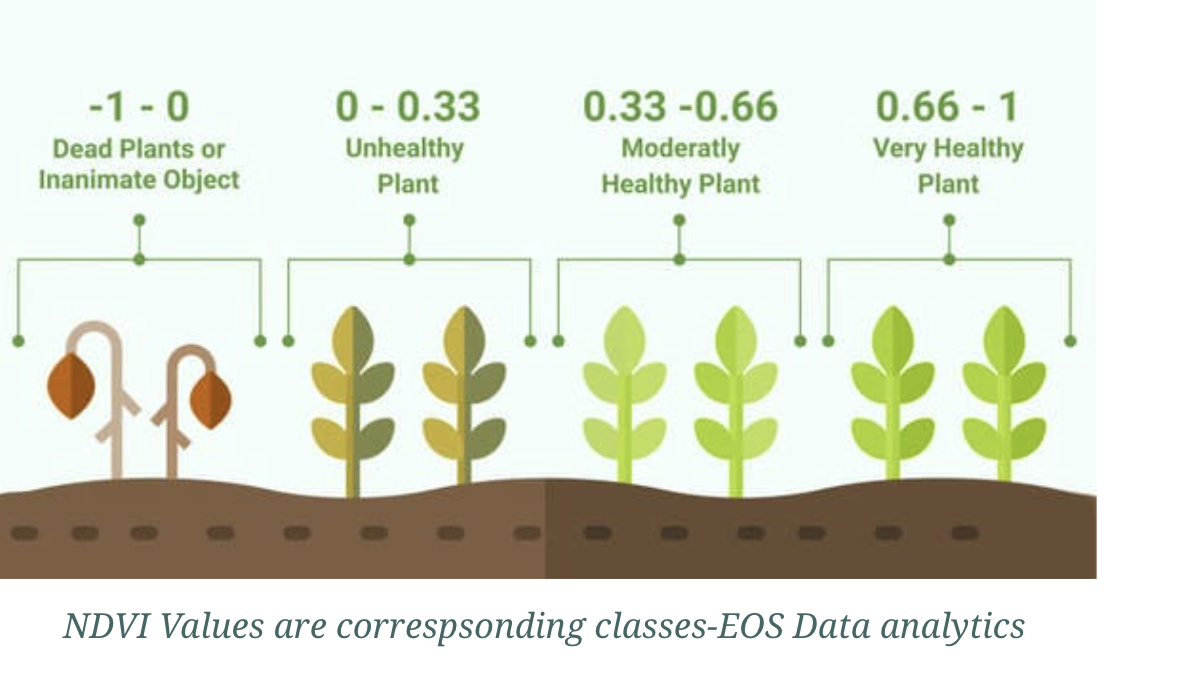 https://storymaps.arcgis.com/stories/47d57669202f4aa38739a294747ea28f
 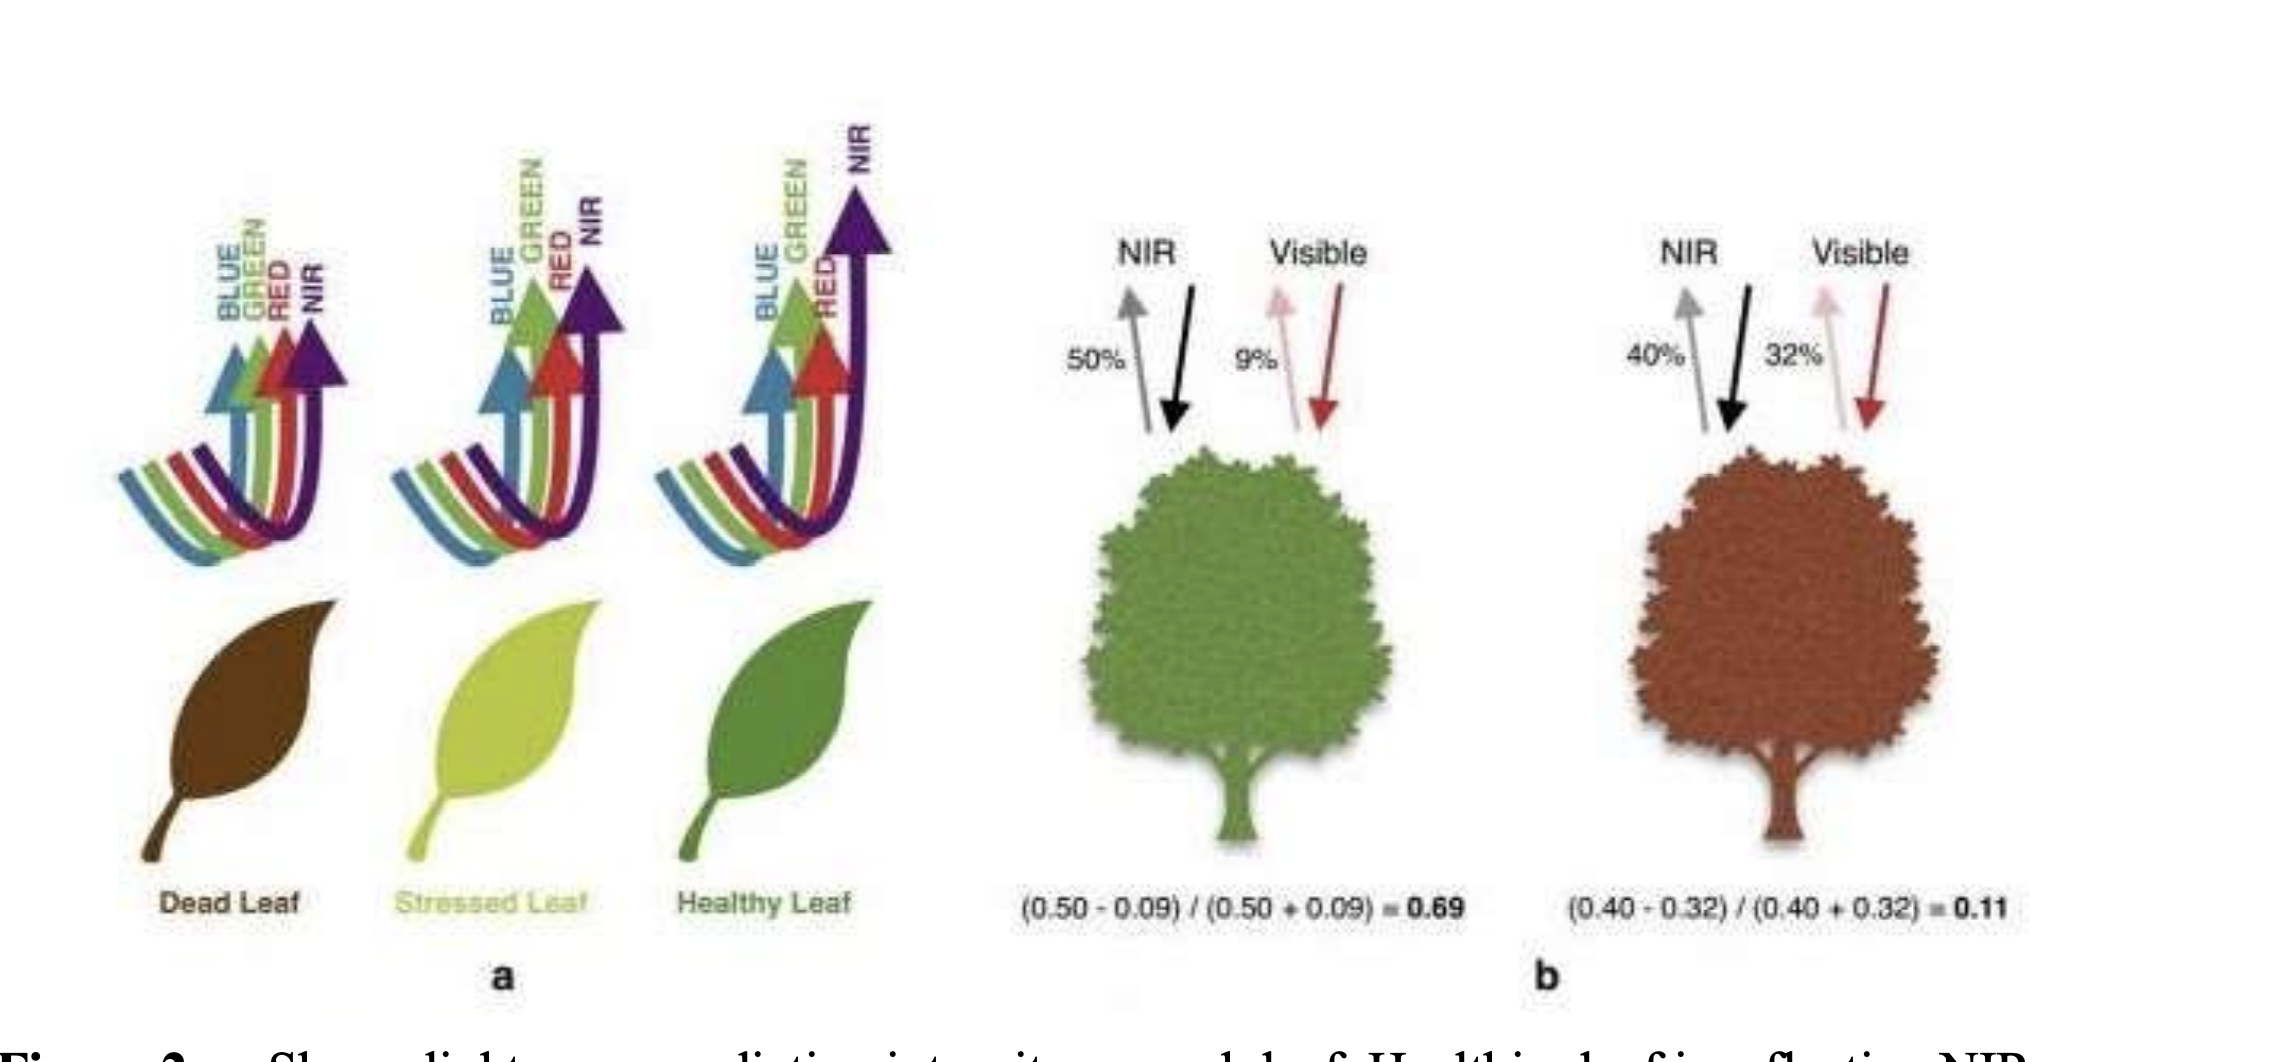
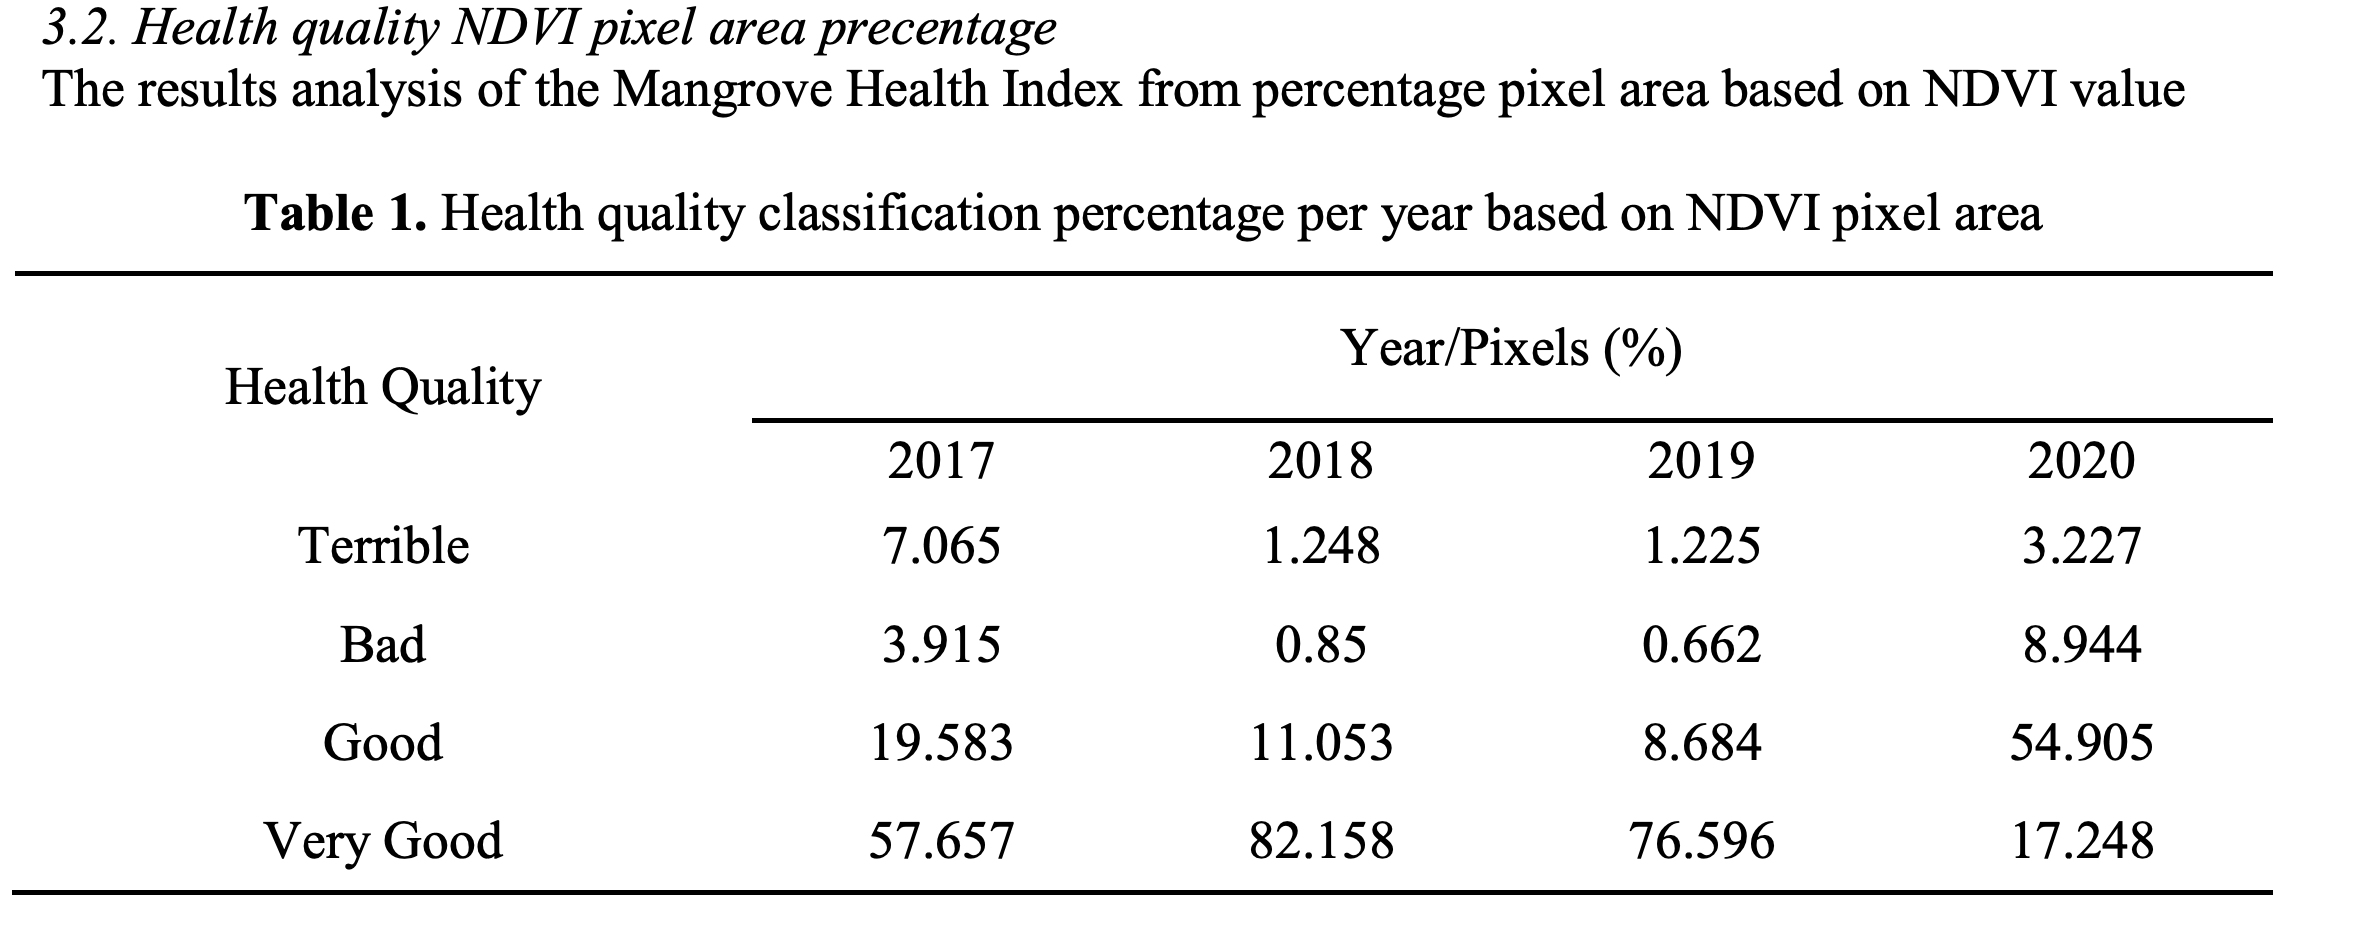
We used same season and same satelite did we do L1C or L2A?


## The following section explores yearly comparison of NDVI as a means of analyzing mangrove distribution/ growth/ loss and other statistical inferences. It does thresholding, historgram plots for comparison, mean/ std dev between years and other means to try and anaylze mangrove behavior in this region.

In [ ]:
#Non Filtered NDVI
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
NDVI_2017 = comp_2017['NDVI'].clip(min=-1, max=1)
NDVI_2026 = comp_2026['NDVI'].clip(min=-1, max=1)

comp_2017['NDVI'].plot.imshow(ax=ax[0], cmap='YlGn', vmin=-1, vmax=1)
ax[0].set_title('2017 NDVI')
comp_2026['NDVI'].plot.imshow(ax=ax[1], cmap='YlGn',vmin=-1, vmax=1)
ax[1].set_title('2026 NDVI')

plt.tight_layout()
#plt.savefig('2016 vs 2026 NDVI', dpi=300, bbox_inches='tight')

In [ ]:
# Histogram plot of yearly distributions
fig, ax = plt.subplots(2, 1)
NDVI_2017.plot.hist(ax=ax[0], bins=50)
NDVI_2026.plot.hist(ax=ax[1], bins=50)
ax[0].set_title('NDVI 2017 Distribution')
ax[1].set_title('NDVI 2026 Distribution')
plt.tight_layout()

In [ ]:
# Filtered NDVI Samples Year
filtered_NDVI_2026 = comp_2026['NDVI'].where(comp_2026['NDVI'] >0)
filtered_NDVI_2017 = comp_2017['NDVI'].where(comp_2017['NDVI'] >0)
diff_NDVI = filtered_NDVI_2026 - filtered_NDVI_2017
fig, ax = plt.subplots(1, 2, figsize=(12,5))
filtered_NDVI_2017.plot.imshow(ax=ax[0], cmap='YlGn', vmin=-1, vmax=1)
ax[0].set_title('2017 NDVI')
filtered_NDVI_2026.plot.imshow(ax=ax[1], cmap='YlGn',vmin=-1, vmax=1)
ax[1].set_title('2026 NDVI')

plt.tight_layout()
plt.savefig('2016 vs 2026 NDVI Filtered', dpi=300, bbox_inches='tight')

In terms of differentiating whether filtered or unfiltered is best to use, it comes down to map visualization. For all statistical equations, the unfiltered is used (including gain/ loss) but for visualization the filtered elimates water and other and types not apart of this analysis. 

In [ ]:
#Using the Science Direct articles suggestions for thresholding with NDVI including mangroves

total_pixels_2017 = NDVI_2017.count().item()
total_pixels_2026 = NDVI_2026.count().item()

good_2017 = (NDVI_2017 >= 0.4) & (NDVI_2017 <= .68)
good_2026 = (NDVI_2026 >= 0.4) & (NDVI_2026 <= .68)
good_pixels_2017 = good_2017.sum().item()
good_pixels_2026 = good_2026.sum().item()

stressed_2017 = (NDVI_2017 >= 0.38) & (NDVI_2017 <= .47)
stressed_2026 = (NDVI_2026 >= 0.38) & (NDVI_2026 <= .47)
stressed_pixels_2017 = stressed_2017.sum().item()
stressed_pixels_2026 = stressed_2026.sum().item()


percent_good_2017 = (good_pixels_2017 / total_pixels_2017) * 100
percent_good_2026 = (good_pixels_2026 / total_pixels_2026) * 100

percent_stressed_2017 = (stressed_pixels_2017 / total_pixels_2017) * 100
percent_stressed_2026 = (stressed_pixels_2026 / total_pixels_2026) * 100

print(f"2017 Healthy young/ dense mature mangroves: {percent_good_2017:.2f}%")
print(f"2017 Environmental stressed mangroves: {percent_stressed_2017:.2f}%")

print(f"2026 Healthy young/ dense mature mangroves: {percent_good_2017:.2f}%")
print(f"2026 Environmental stressed mangroves: {percent_stressed_2026:.2f}%")


In [ ]:
#Turning this into a pandas table 
data = {
    "Category": [
        "Healthy young / dense mature mangroves",
        "Environmentally stressed mangroves"
    ],
    "NDVI Threshold": [
        "0.40 – 0.68",
        "0.38 – 0.47"
    ],
    "2017 (%)": [
        round(percent_good_2017, 1),
        round(percent_stressed_2017, 1)
    ],
    "2026 (%)": [
        round(percent_good_2026, 1),
        round(percent_stressed_2026, 1)
    ]
}

ndvi_summary_table = pd.DataFrame(data)

#dfi.export(ndvi_summary_table, "threshold_ndvi_2.png", table_conversion="matplotlib")

In [ ]:
#Using the ARCGIS suggestion for different health of plants as NDVI threshold

very_healthy_2017 = (NDVI_2017 >= 0.66) & (NDVI_2017 <= 1)
very_healthy_2026 = (NDVI_2026 >= 0.66) & (NDVI_2026 <= 1)
very_healthy_pixels_2017 = very_healthy_2017.sum().item()
very_healthy_pixels_2026 = very_healthy_2026.sum().item()

healthy_2017 = (NDVI_2017 >= 0.33) & (NDVI_2017 <= .66)
healthy_2026 = (NDVI_2026 >= 0.33) & (NDVI_2026 <= .66)
healthy_pixels_2017 = healthy_2017.sum().item()
healthy_pixels_2026 = healthy_2026.sum().item()

unhealthy_2017 = (NDVI_2017 >= 0) & (NDVI_2017 <= .33)
unhealthy_2026 = (NDVI_2026 >= 0) & (NDVI_2026 <= .33)
unhealthy_pixels_2017 = unhealthy_2017.sum().item()
unhealthy_pixels_2026 = unhealthy_2026.sum().item()

percent_very_healthy_2017 = (very_healthy_pixels_2017 / total_pixels_2017) * 100
percent_very_healthy_2026 = (very_healthy_pixels_2026 / total_pixels_2026) * 100

percent_healthy_2017 = (healthy_pixels_2017 / total_pixels_2017) * 100
percent_healthy_2026 = (healthy_pixels_2026 / total_pixels_2026) * 100

percent_unhealthy_2017 = (unhealthy_pixels_2017 / total_pixels_2017) * 100
percent_unhealthy_2026 = (unhealthy_pixels_2026 / total_pixels_2026) * 100

print(f"2017 Very Healthy NDVI: {percent_very_healthy_2017:.2f}%")
print(f"2017 Healthy NDVI: {percent_healthy_2017:.2f}%")
print(f"2017 Unhealthy NDVI: {percent_unhealthy_2017:.2f}%")

print(f"2026 Very Healthy NDVI: {percent_very_healthy_2026:.2f}%")
print(f"2026 Healthy NDVI: {percent_healthy_2026:.2f}%")
print(f"2026 Unhealthy NDVI: {percent_unhealthy_2026:.2f}%")

In [ ]:
#Turning this into pandas table

data2 = {
    "Category": ["Very Healthy", "Healthy", "Unhealthy"],
    "NDVI Threshold": ["0.66 – 1.00", "0.33 – 0.66", "0.00 – 0.33"],
    "2017 (%)": [
        round(percent_very_healthy_2017, 1),
        round(percent_healthy_2017, 1),
        round(percent_unhealthy_2017, 1)
    ],
    "2026 (%)": [
        round(percent_very_healthy_2026, 1),
        round(percent_healthy_2026, 1),
        round(percent_unhealthy_2026, 1)
    ]
}

ndvi_summary_table2 = pd.DataFrame(data2)

#dfi.export(ndvi_summary_table2, "threshold_ndvi_1.png", table_conversion="matplotlib")

In [ ]:
#Looking at difference using unfiltered data.


diff_NDVI_unfiltered = NDVI_2026 - NDVI_2017

fig, ax = plt.subplots()
diff_NDVI_unfiltered.plot.imshow(ax=ax,
    cmap="RdYlGn",
    vmin=-.5,
    vmax=.5
)
plt.title("NDVI Change (2026 - 2017)")
plt.tight_layout()
#plt.savefig('2016 vs 2026 NDVI', dpi=300, bbox_inches='tight')

In [ ]:
#NDVI change distribution map
diff_NDVI.plot.hist(bins=50)
plt.title("NDVI Change Distribution")
#plt.savefig('NDVI Change Histogram', dpi=300, bbox_inches='tight')

In [ ]:
# Filtered NDVI Comparison
fig, ax = plt.subplots()
diff_NDVI.plot.imshow(ax=ax,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)
plt.title("NDVI Change (2026 - 2017)")
plt.tight_layout()

Using the difference of the masked leads to too much data being altered, it turns unreliable and starts to question whether it's jsut density difference.


# Thresholding using the NDVI 
This threshold was found visually through the unfiltered NDVI difference map, as well as the histogram of the change and were it starts to have a tail.

In [ ]:
new_mangrove_mask = diff_NDVI_unfiltered > 0.25

In [ ]:
# Side by side comparison of the NDVI change with the new boolean mask graph, ideally to represent new mangrove growth 
fig, ax = plt.subplots(1,2, figsize=(12,4))

diff_NDVI.plot.imshow(ax=ax[0],
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)
ax[0].set_title("NDVI Change (2026 - 2017)")

new_mangrove_mask.plot.imshow(ax=ax[1], cmap="viridis")
ax[1].set_title("New Mangrove (Threshold = 0.25)")

plt.tight_layout()
#plt.savefig('Threshold and NDVI change', dpi=300, bbox_inches='tight')

In [ ]:
# Finding mean change and standard deviation of change 

mean_change = diff_NDVI.mean().item()
print(f"Mean NDVI change: {mean_change:.2f}")
std_change = diff_NDVI.std().item()
print(f"NDVI change std: {std_change:.2f}")

In [ ]:
#Attempting to calssify any slight losses or changes to density or the mangroves 

gain = (diff_NDVI > 0.1)
loss = (diff_NDVI < -0.1)
stable = (abs(diff_NDVI) <= 0.1)

total_pixels = diff_NDVI.count().item()

gain_pct = gain.sum().item() / total_pixels * 100
loss_pct = loss.sum().item() / total_pixels * 100
stable_pct = stable.sum().item() / total_pixels * 100

print(f"Vegetation Gain: {gain_pct:.2f}%")
print(f"Vegetation Loss: {loss_pct:.2f}%")
print(f"Stable: {stable_pct:.2f}%")


# MNDWI
Modified Normalized Difference Water Index
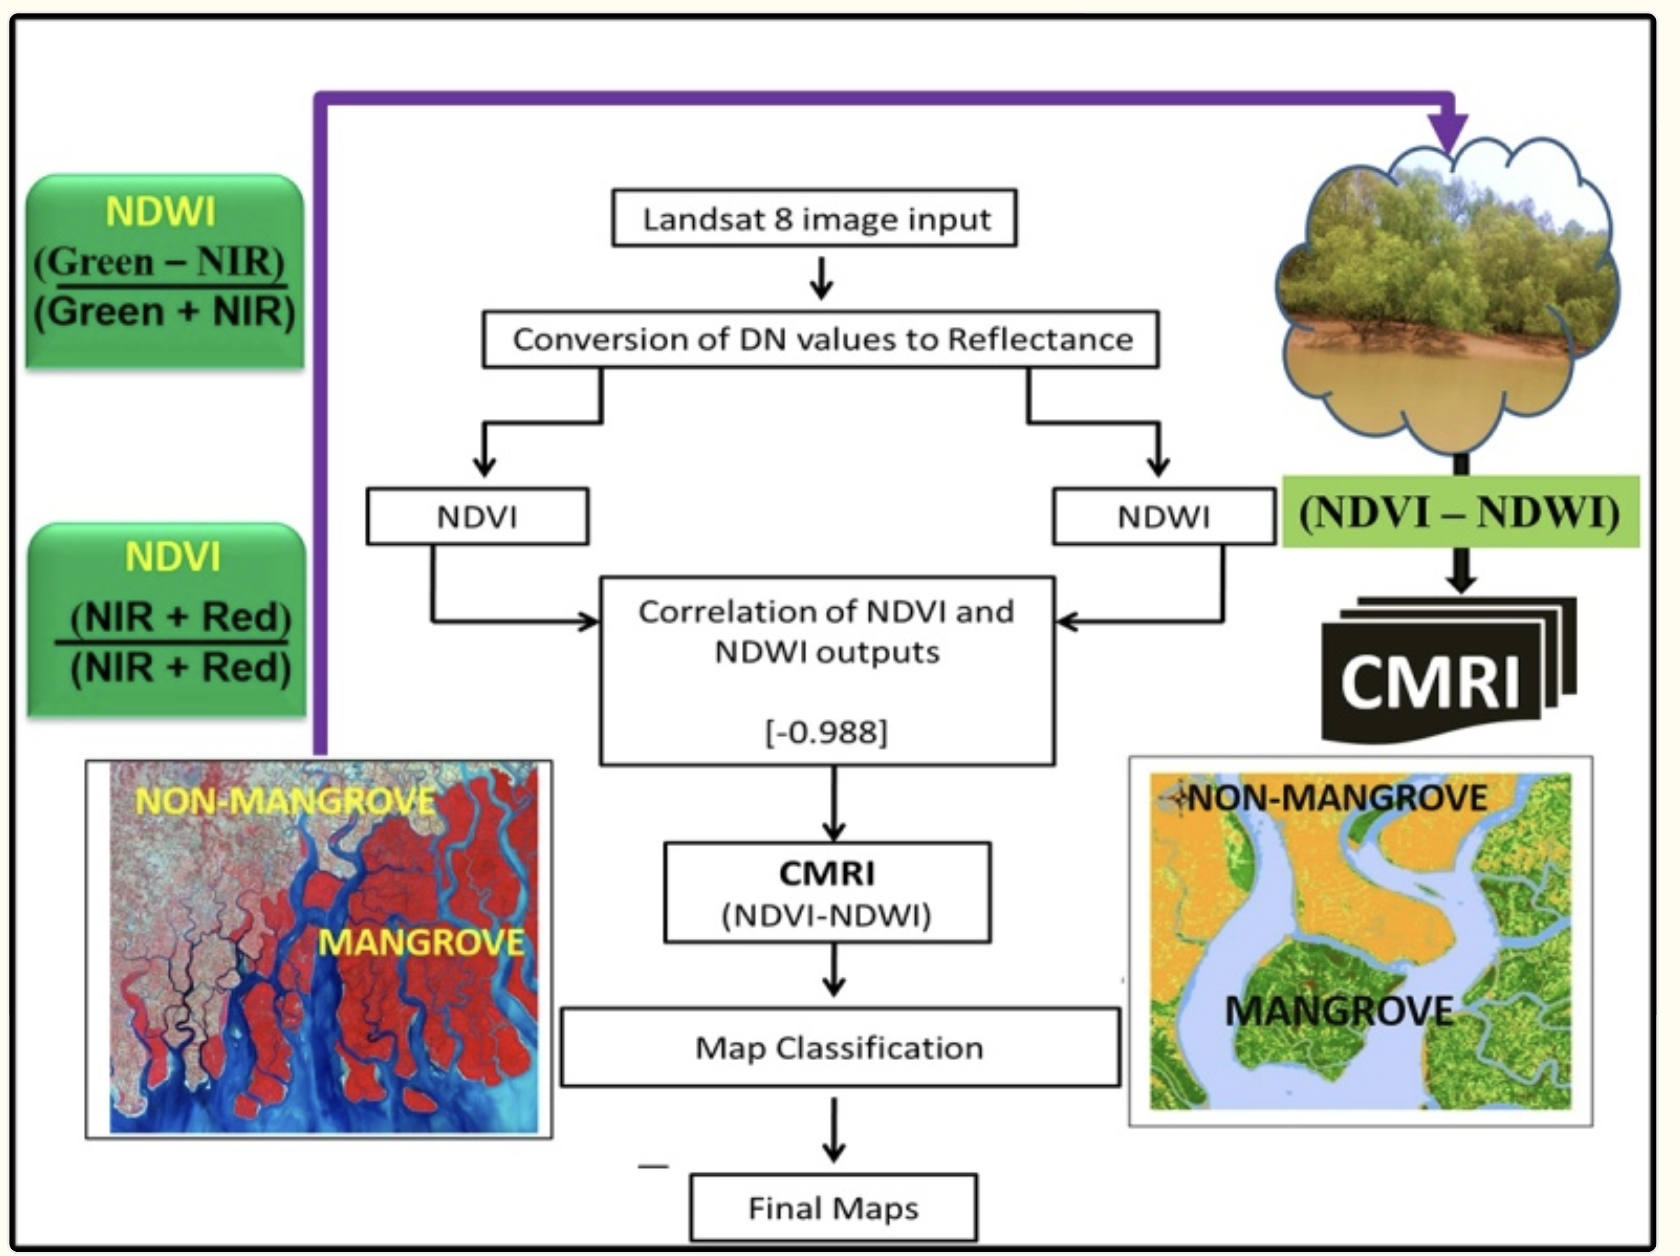
namely ‘Combined Mangrove Recognition Index (CMRI)’ incorporates outputs from NDVI and NDWI indices in order to assess exclusively the mangrove vegetation using information like greenness and water content (succulence). (used later)
Important for seeing water level rising maybe?



While MNDWI/ NDWI do not give information about mangroves directly, they are integral to the mangrove index. Mangroves by nature are in tidal falts/ mud plains etc so water index helps account for that.

In [ ]:
# MNDWI yearly comparison

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
MNDWI_2017 = comp_2017['MNDWI'].clip(min=-1, max=1)
MNDWI_2026 = comp_2026['MNDWI'].clip(min=-1, max=1)

MNDWI_2017.plot.imshow(ax=ax[0], cmap='Purples')
ax[0].set_title('2017 MNDWI')
MNDWI_2026.plot.imshow(ax=ax[1], cmap='Purples')
ax[1].set_title('2026 MNDWI')

plt.tight_layout()



#There is obviously something off aobut the two water indexs and they are very different which would make it hard to compare 

In [ ]:
# MNDWI yearly distribution - this was most important when noticing the difference in the two years between the Sentinel data

fig, ax = plt.subplots(2, 1)
MNDWI_2017.plot.hist(ax=ax[0], bins=50)
MNDWI_2026.plot.hist(ax=ax[1], bins=50)
ax[0].set_title('MNDWI 2017 Distribution')
ax[1].set_title('MNDWI 2026 Distribution')
plt.tight_layout()

In [ ]:
# Looking at NDWI comparison as well

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
NDWI_2017 = comp_2017['NDWI'].clip(min=-1, max=1)
NDWI_2026 = comp_2026['NDWI'].clip(min=-1, max=1)

NDWI_2017.plot.imshow(ax=ax[0], cmap='Purples', vmin=-1, vmax=1)
ax[0].set_title('2017 NDWI')
NDWI_2026.plot.imshow(ax=ax[1], cmap='Purples', vmin=-1, vmax=1)
ax[1].set_title('2026 NDWI')

plt.tight_layout()

In [ ]:
diff_MNDWI = MNDWI_2026 - MNDWI_2017
diff_MNDWI.plot.imshow()
plt.show()
diff_MNDWI.plot.imshow(
    cmap="RdBu",
    vmin=-0.5,
    vmax=0.5
)
plt.title("MNDWI Change (2026 - 2017)")
plt.show()

# CMRI
"The Sentinel-2A data were used to detect changes in the extent of coastal mangrove forests using the visual interpretation approach in combination with the CMRI thresholds defined (CMRI > 0.47 for mangrove forests, -0.25 < CMRI ≤ 0.47 for non-mangrove forests, and CMRI ≤ -0.25 for areas covered water). The overall accuracy assessments of land covers in each selected year (2016, 2017, 2018, 2019, 2020, 2021, and 2022) are greater than 93.0% with Kappa coefficient more than 0.89,"
https://www.researchgate.net/publication/363305505_USING_SENTINEL-2A_DERIVED_CMRI_FOR_MANGROVE_COVER_MAPPING_OVER_7_YEARS_2016-2022_IN_QUANG_YEN_QUANG_NINH_PROVINCE

## The following section explores yearly comparison of CMRI as a means of analyzing mangrove distribution/ growth/ loss and other statistical inferences. It does thresholding, historgram plots for comparison, mean/ std dev between years and other means to try and anaylze mangrove behavior in this region (just as NDVI) Yet CMRI is considered up to 93% more accurate then other indexing due to it's integration of MNDWI. Mangroves have a high moisture content and are much greener then other vegetation.

In [ ]:
# Finding the actual difference in all pixels across the years
CMRI_2017 = comp_2017['CMRI'].clip(min=-1, max=1)
CMRI_2026 = comp_2026['CMRI'].clip(min=-1, max=1)
diff_CMRI = CMRI_2026 - CMRI_2017

#Filtered Difference in pixels (normalizing it)
filtered_2026 = comp_2026['CMRI'].where(comp_2026['CMRI'] >0)
filtered_2017 = comp_2017['CMRI'].where(comp_2017['CMRI'] >0)
diff = filtered_2026 - filtered_2017

#Unfiltered all pixels yearly 
CMRI_2017 = comp_2017['CMRI'].clip(min=-1, max=1)
CMRI_2026 = comp_2026['CMRI'].clip(min=-1, max=1)

In [ ]:
# Normalized/ filtered yearly comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


filtered_2017.plot.imshow(ax=ax[0], cmap="BrBG")

ax[0].set_title('2017 CMRI')
filtered_2026.plot.imshow(ax=ax[1], cmap="BrBG")
ax[1].set_title('2026 CMRI')

plt.tight_layout()
#plt.savefig('2017 vs 2026 CMRI', dpi=300, bbox_inches='tight')



In [ ]:
# Overlaying the NDVI and CMRI

fig, ax = plt.subplots(figsize=(12, 5))
filtered_NDVI_2026.plot.imshow(ax=ax, cmap='RdBu',vmin=-1, vmax=1, zorder=2)
filtered_2026.plot.imshow(ax=ax, cmap="BrBG", zorder=1)
ax.set_title('2026 CMRI')

In [ ]:
# All pixels yearly comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


CMRI_2017.plot.imshow(ax=ax[0], cmap="BrBG")
ax[0].set_title('2017 CMRI')
CMRI_2026.plot.imshow(ax=ax[1], cmap="BrBG")
ax[1].set_title('2026 CMRI')

plt.tight_layout()

In [ ]:
#CMRI > 0.47 for mangrove forests, -0.25 < CMRI ≤ 0.47 for non-mangrove forests, and CMRI ≤ -0.25 for areas covered water
# UNFINISHED


total_pixels_2017 = CMRI_2017.count().item()
total_pixels_2026 = CMRI_2026.count().item()






g_2017 = (NDVI_2017 >= 0.4) & (NDVI_2017 <= .68)
good_2026 = (NDVI_2026 >= 0.4) & (NDVI_2026 <= .68)
good_pixels_2017 = good_2017.sum().item()
good_pixels_2026 = good_2026.sum().item()

stressed_2017 = (NDVI_2017 >= 0.38) & (NDVI_2017 <= .47)
stressed_2026 = (NDVI_2026 >= 0.38) & (NDVI_2026 <= .47)
stressed_pixels_2017 = stressed_2017.sum().item()
stressed_pixels_2026 = stressed_2026.sum().item()


percent_good_2017 = (good_pixels_2017 / total_pixels_2017) * 100
percent_good_2026 = (good_pixels_2026 / total_pixels_2026) * 100

percent_stressed_2017 = (stressed_pixels_2017 / total_pixels_2017) * 100
percent_stressed_2026 = (stressed_pixels_2026 / total_pixels_2026) * 100

print(f"2017 Healthy young/ dense mature mangroves: {percent_good_2017:.2f}%")
print(f"2017 Environmental stressed mangroves: {percent_stressed_2017:.2f}%")

print(f"2026 Healthy young/ dense mature mangroves: {percent_good_2017:.2f}%")
print(f"2026 Environmental stressed mangroves: {percent_stressed_2026:.2f}%")

In [ ]:
#Filered/ Normalized CMRI distribution

fig, ax = plt.subplots(1,2 , figsize=(12,4))
filtered_2017.plot.hist(ax=ax[0], bins=100)
ax[0].set_title('2017 CMRI Distribution')
filtered_2026.plot.hist(ax=ax[1], bins=100)
ax[1].set_title('2026 CMRI Distribution')


In [ ]:
#Non filtered CMRI distribution

fig, ax = plt.subplots(1,2 , figsize=(12,4))
CMRI_2017.plot.hist(ax=ax[0], bins=50)
ax[0].set_title('2017 CMRI Distribution')
CMRI_2026.plot.hist(ax=ax[1], bins=50)
ax[1].set_title('2026 CMRI Distribution')

In [ ]:
#Using non filtered and threshold from Quang and Nguyen (0.47) to identify mangrove forests

total_pixels_2017 = CMRI_2017.count().item()
total_pixels_2026 = CMRI_2026.count().item()

mangrove_2017 = CMRI_2017 >= 0.47
mangrove_2026 = CMRI_2026 >= 0.47
good_pixels_2017 = mangrove_2017.sum().item()
good_pixels_2026 = mangrove_2026.sum().item()



percent_mangrove_2017 = (good_pixels_2017 / total_pixels_2017) * 100
percent_mangrove_2026 = (good_pixels_2026 / total_pixels_2026) * 100


print(f"2017 Mangrove Forests : {percent_mangrove_2017:.2f}%")

print(f"2026 Mangrove Forests: {percent_mangrove_2026:.2f}%")



In [ ]:
#NDVI Change in years with non normalized data 

fig, ax = plt.subplots()
diff_CMRI.plot.imshow(ax=ax, cmap="BrBG", vmin=-1, vmax=1)
ax.set_title('NDVI Change 2017-2026')
#plt.savefig('CMRI_change', dpi=300, bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
diff_CMRI.plot.hist(ax=ax[0], bins=50)
ax[0].set_title('CMRI Unfiltered Change 2017-2026')
diff.plot.hist(ax=ax[1], bins=50)
ax[1].set_title('CMRI Filtered Change 2017-2026')
plt.tight_layout()

#plt.savefig('2017 vs 2026 CMRI Filtered vs Unfiltered distribution', dpi=300, bbox_inches='tight')

In [ ]:
# Finding mean change and standard deviation of change 

mean_change_CMRI = diff_CMRI.mean().item()
print(f"Mean CMRI change: {mean_change_CMRI:.2f}")
std_change_CMRI = diff_CMRI.std().item()
print(f"CMRI change std: {std_change_CMRI:.2f}")

Creating a mask of negative/ positive process of change using previous. This was difficult thresholding because water values were interfering but I wanted to use all pixel values and not just the filtered ones because the tidal falts and in land shrimp ponds are all water areas that could have mangroves in them as well. I thought based off the histogram, maybe I should use the filtered change and use that little bump to the very right, but I think that may a cause of planted forests. It's ahrd to differentiate between density increse/ decrease and mangrove forest clearance. So these thresholds were mostly picked visually with a bit of histogram distribution inference.


In [ ]:

new_mangrove_mask =diff_CMRI > 0.75
dead_mangrove_mask = diff_CMRI < -.50

In [ ]:
#Plotting the change in CMRI with the positive/ negative process of change boolean graphs
fig, ax = plt.subplots(3, 1, figsize=(5,12))

diff.plot.imshow(ax=ax[0],
    cmap="BrBG",
    vmin=-1,
    vmax=1
)
ax[0].set_title("CMRI Change (2026 - 2017)")

new_mangrove_mask.plot.imshow(ax=ax[1], cmap="viridis")
ax[1].set_title("Positive Process of Change (Threshold = 0.75)")
dead_mangrove_mask.plot.imshow(ax=ax[2], cmap="viridis")
ax[2].set_title("Negative Process of Change (Threshold = -0.50)")
plt.tight_layout()
#plt.savefig('CMRI_change_threshold', dpi=300, bbox_inches='tight')

In [ ]:
# Calculate Area in hectare- each pixel is 100 m^2. Doing this for overall magrove forests and the positive/ negative process iof change 

total_pixels_2017 = CMRI_2017.count().item()
total_pixels_2026 = CMRI_2026.count().item()


#Total Area of raster 2017
pixel_area_ha_2017 = total_pixels_2017 * .01 
print(pixel_area_ha)

#Total area of mangrove forests 2017
mangrove_area_ha_2017 = good_pixels_2017 * .01
print(mangrove_area_ha)

#Total area of raster 2026
pixel_area_ha_2026 = total_pixels_2026 * .01 
print(pixel_area_ha_2026)

#Total area of mangrove forests 2026
mangrove_area_ha_2026 = good_pixels_2026 * .01
print(mangrove_area_ha_2026)

#Total area of mangrove positive change from 2017-2026
new_pixels_2026 = new_mangrove_mask.sum().item()
new_area_ha = new_pixels_2026 * .01
print(new_area_ha)

#Total area of mangrove negative change from 2017 - 2026
dead_pixels_2026 = dead_mangrove_mask.sum().item()
dead_area_ha = dead_pixels_2026 * .01
print(dead_area_ha)


#CREATING a pandas data frame
data_area = {
    "Metric": [
        "Total Raster Area 2017",
        "Mangrove Area 2017",
        "Total Raster Area 2026",
        "Mangrove Area 2026",
        "Mangrove Gain (2017–2026)",
        "Mangrove Loss (2017–2026)"
    ],
    "Area (ha)": [
        round(pixel_area_ha_2017, 2),
        round(mangrove_area_ha_2017, 2),
        round(pixel_area_ha_2026, 2),
        round(mangrove_area_ha_2026, 2),
        round(new_area_ha, 2),
        round(dead_area_ha, 2)
    ]
}

df_areas = pd.DataFrame(data_area)

#dfi.export(df_areas, "Areas.png", table_conversion="matplotlib")



In [ ]:
#Doing Same pixel to new mask/ dead mask ratio

gain = new_mangrove_mask
loss = dead_mangrove_mask
stable = (abs(diff_CMRI) <= 0.1)

total_pixels = diff_CMRI.count().item()

gain_pct = gain.sum().item() / total_pixels * 100
loss_pct = loss.sum().item() / total_pixels * 100
stable_pct = stable.sum().item() / total_pixels * 100

print(f'Vegetation Gain: {gain_pct:.2f}%')
print(f'Vegetation Loss: {loss_pct:.2f}%')
print(f'Stable: {stable_pct:.2f}%')


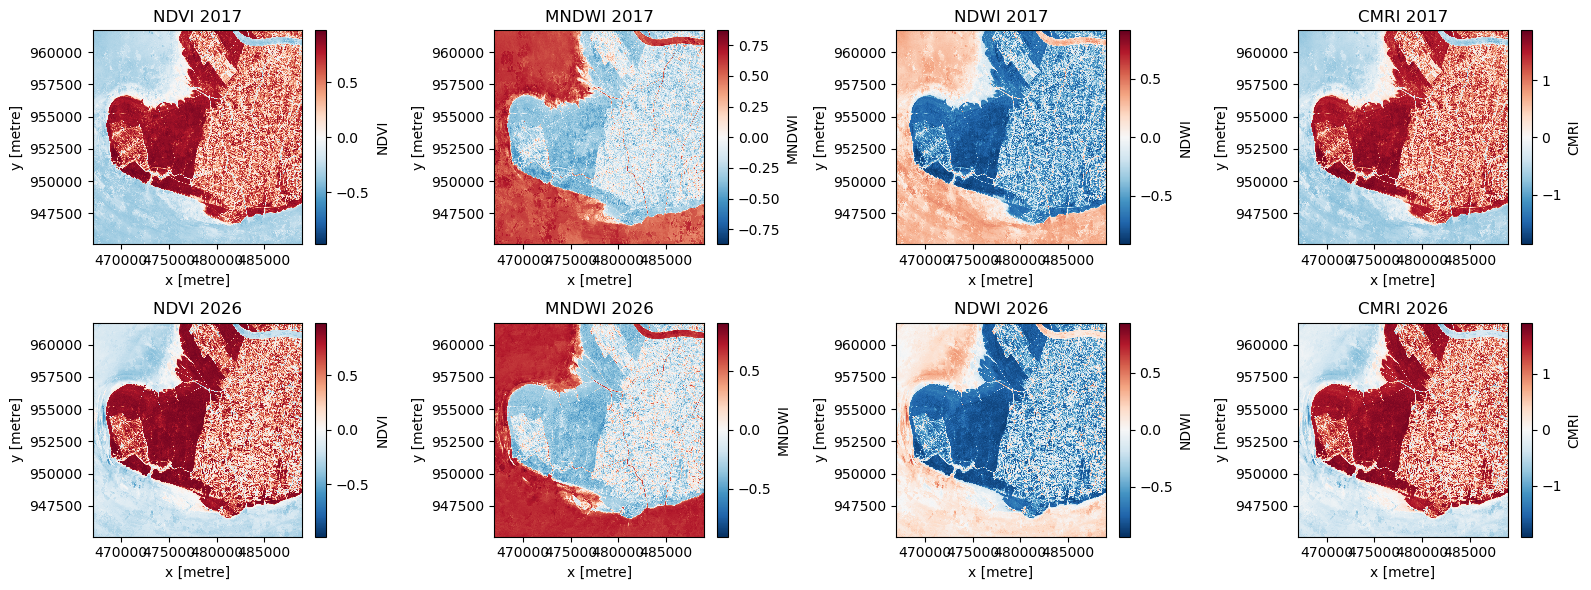

In [50]:
#Composite graphs
band_types1 = ['NDVI', 'MNDWI', 'NDWI', 'CMRI']
titles = ['NDVI', 'MNDWI', 'NDWI', 'CMRI']

fig, ax = plt.subplots(2, 4, figsize=(16, 6))

for i, (band, title) in enumerate(zip(band_types1, titles)):
    comp_2017[band].plot.imshow(ax=ax[0, i])
    ax[0, i].set_title(f"{title} 2017")

    comp_2026[band].plot.imshow(ax=ax[1, i])
    ax[1, i].set_title(f"{title} 2026")

plt.tight_layout()


# Do i keep indexing the same throughout years??